In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("compressed_data.csv")

C:\Users\jeeva\AppData\Local\Temp\ipykernel_29332\1184112827.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("compressed_data.csv")


In [3]:
df

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102594,6092437,Spare room in Williamsburg,12312296767,verified,Krik,Brooklyn,Williamsburg,40.70862,-73.94651,United States,...,$169,1.0,0.0,NaN,NaN,3.0,1.0,227.0,No Smoking No Parties or Events of any kind Pl...,NaN
102595,6092990,Best Location near Columbia U,77864383453,unconfirmed,Mifan,Manhattan,Morningside Heights,40.80460,-73.96545,United States,...,$167,1.0,1.0,7/6/2015,0.02,2.0,2.0,395.0,House rules: Guests agree to the following ter...,NaN
102596,6093542,"Comfy, bright room in Brooklyn",69050334417,unconfirmed,Megan,Brooklyn,Park Slope,40.67505,-73.98045,United States,...,$198,3.0,0.0,NaN,NaN,5.0,1.0,342.0,NaN,NaN
102597,6094094,Big Studio-One Stop from Midtown,11160591270,unconfirmed,Christopher,Queens,Long Island City,40.74989,-73.93777,United States,...,$109,2.0,5.0,10/11/2015,0.10,3.0,1.0,386.0,NaN,NaN


In [4]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

# Checking missing values

In [5]:
print(df.isnull().sum())

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [6]:
df.info

<bound method DataFrame.info of              id                                              NAME  \
0       1001254                Clean & quiet apt home by the park   
1       1002102                             Skylit Midtown Castle   
2       1002403               THE VILLAGE OF HARLEM....NEW YORK !   
3       1002755                                               NaN   
4       1003689  Entire Apt: Spacious Studio/Loft by central park   
...         ...                                               ...   
102594  6092437                        Spare room in Williamsburg   
102595  6092990                     Best Location near Columbia U   
102596  6093542                    Comfy, bright room in Brooklyn   
102597  6094094                  Big Studio-One Stop from Midtown   
102598  6094647                              585 sf Luxury Studio   

            host id host_identity_verified    host name neighbourhood group  \
0       80014485718            unconfirmed     Madaline     

# Handling missing values

In [8]:
df['last review'] = pd.to_datetime(df['last review'], errors = 'coerce')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102599 non-null  int64         
 1   NAME                            102349 non-null  object        
 2   host id                         102599 non-null  int64         
 3   host_identity_verified          102310 non-null  object        
 4   host name                       102193 non-null  object        
 5   neighbourhood group             102570 non-null  object        
 6   neighbourhood                   102583 non-null  object        
 7   lat                             102591 non-null  float64       
 8   long                            102591 non-null  float64       
 9   country                         102067 non-null  object        
 10  country code                    102468 non-null  object 

In [11]:
df.fillna({'reviews per month': 0, 'last review': df['last review'].min()},inplace = True)

In [13]:
df.dropna(subset = ['NAME', 'host name'], inplace= True)

In [14]:
print(df.isnull().sum())

id                                     0
NAME                                   0
host id                                0
host_identity_verified               276
host name                              0
neighbourhood group                   26
neighbourhood                         16
lat                                    8
long                                   8
country                              526
country code                         122
instant_bookable                      96
cancellation_policy                   70
room type                              0
Construction year                    200
price                                239
service fee                          268
minimum nights                       403
number of reviews                    182
last review                            0
reviews per month                      0
review rate number                   314
calculated host listings count       318
availability 365                     420
house_rules     

In [15]:
df = df.drop(columns = ['license', 'house_rules'], errors = 'ignore')

In [16]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,2020.0,$966,$193,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,2007.0,$142,$28,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,2005.0,$620,$124,3.0,0.0,2012-07-11,0.00,5.0,1.0,352.0
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,2009.0,$204,$41,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0
5,1004098,Large Cozy 1 BR Apartment In Midtown East,45498551794,verified,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,United States,...,2013.0,$577,$115,3.0,74.0,2019-06-22,0.59,3.0,1.0,374.0


In [17]:
# Remove dollar sings and convert to float
df['price'] = df['price'].replace('[\$,]','',regex = True).astype(float)
df['service fee'] = df['service fee'].replace('[\$,]', '', regex = True).astype(float)

# Remove duplicates

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101949 entries, 0 to 102598
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              101949 non-null  int64         
 1   NAME                            101949 non-null  object        
 2   host id                         101949 non-null  int64         
 3   host_identity_verified          101673 non-null  object        
 4   host name                       101949 non-null  object        
 5   neighbourhood group             101923 non-null  object        
 6   neighbourhood                   101933 non-null  object        
 7   lat                             101941 non-null  float64       
 8   long                            101941 non-null  float64       
 9   country                         101423 non-null  object        
 10  country code                    101827 non-null  object      

# Descriptive statistics

In [21]:
df.describe()

,id,host id,lat,long,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
count,1.019490e+05,1.019490e+05,101941.000000,101941.000000,101749.000000,101710.000000,101681.000000,101546.000000,101767.000000,101949,101949.000000,101635.000000,101631.000000,101529.000000
mean,2.917123e+07,4.924805e+10,40.728078,-73.949654,2012.486314,625.309950,125.029868,8.123176,27.477768,2018-05-17 08:51:02.801989376,1.162350,3.278930,7.948195,141.252933
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,50.000000,10.000000,-1223.000000,0.000000,2012-07-11 00:00:00,0.000000,1.000000,1.000000,-10.000000
25%,1.506897e+07,2.456803e+10,40.688740,-73.982570,2007.000000,340.000000,68.000000,2.000000,1.000000,2017-07-31 00:00:00,0.090000,2.000000,1.000000,3.000000
50%,2.918134e+07,4.910321e+10,40.722300,-73.954440,2012.000000,624.000000,125.000000,3.000000,7.000000,2019-05-23 00:00:00,0.480000,3.000000,1.000000,97.000000
75%,4.320865e+07,7.398468e+10,40.762740,-73.932340,2017.000000,913.000000,183.000000,5.000000,30.000000,2019-07-01 00:00:00,1.710000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2058-06-16 00:00:00,90.000000,5.000000,332.000000,3677.000000
std,1.625395e+07,2.853861e+10,0.055854,0.049495,5.764896,331.605927,66.312772,30.315751,49.486565,NaN,1.682444,1.284943,32.281160,135.423732


# Visualization

# What is the distribution of listing prices?

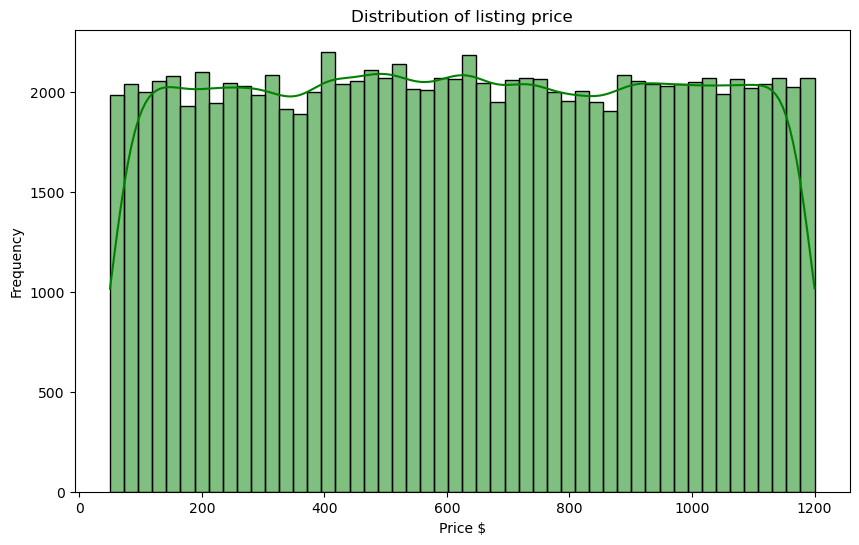

In [24]:
plt.figure(figsize= (10,6))
sns.histplot(df['price'], bins = 50, kde = True, color = 'green')
plt.title("Distribution of listing price")
plt.xlabel("Price $")
plt.ylabel("Frequency")
plt.show()

The histogram shows a fairly even distribution of
listing prices across different price ranges , indicating no
particular concentration of listings in any specific price range.
The KDE line helps visualize this even spread more clearly, 
confirming that the dataset contains listings with a wide variety of prices.

# How are different room types distributed ?

In [25]:
df['room type']

0            Private room
1         Entire home/apt
2            Private room
4         Entire home/apt
5         Entire home/apt
               ...       
102594       Private room
102595       Private room
102596       Private room
102597    Entire home/apt
102598    Entire home/apt
Name: room type, Length: 101949, dtype: object

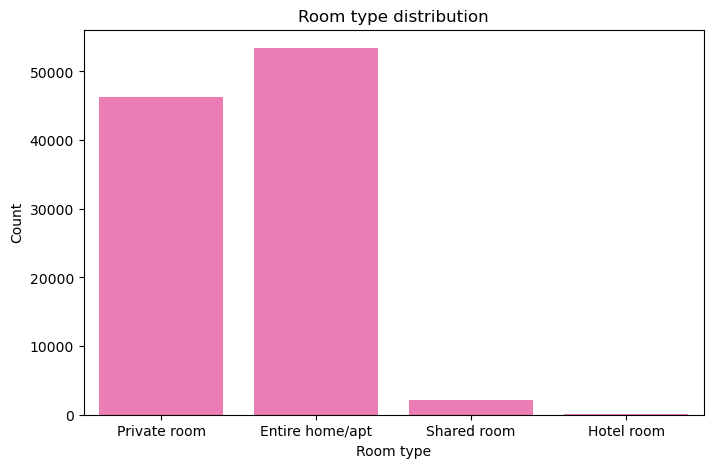

In [29]:
plt.figure(figsize= (8,5))
sns.countplot(x = "room type", data = df, color = "hotpink")
plt.title("Room type distribution")
plt.xlabel("Room type")
plt.ylabel("Count")
plt.show()

# How are listings distributed across different neighbourhoods? 

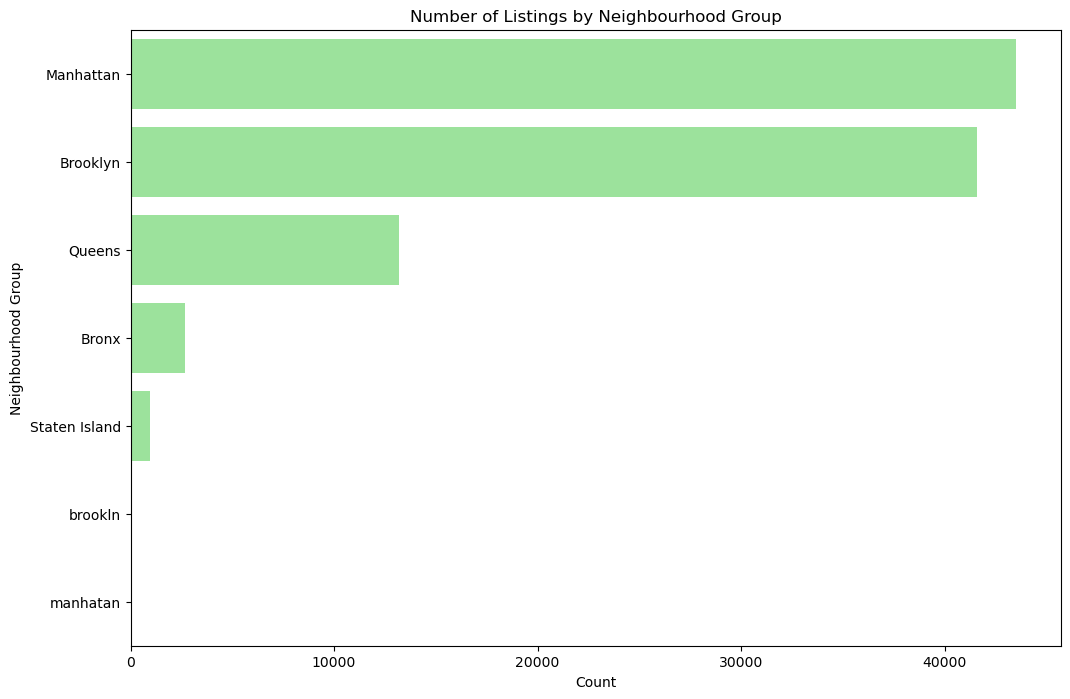

In [30]:
plt.figure(figsize=(12,8))
sns.countplot(y= 'neighbourhood group', data = df, color= 'lightgreen', order = df['neighbourhood group'].value_counts().index)
plt.title("Number of Listings by Neighbourhood Group")
plt.xlabel("Count")
plt.ylabel("Neighbourhood Group")
plt.show()

# What is the relationship between price and room type

C:\Users\jeeva\AppData\Local\Temp\ipykernel_29332\2003646848.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title = 'Room Type')


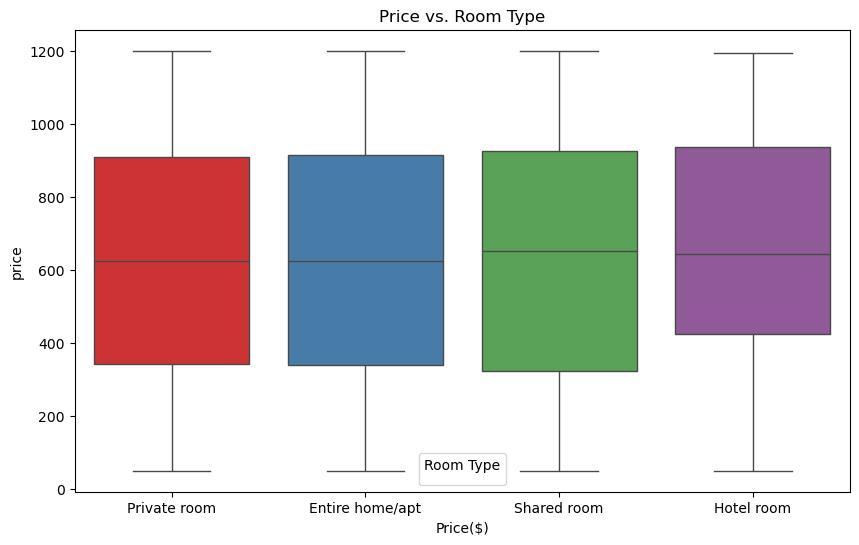

In [32]:
plt.figure(figsize=(10,6))
sns.boxplot(x = 'room type', y = 'price', hue = 'room type', data= df, palette='Set1')
plt.title("Price vs. Room Type")
plt.xlabel("Price($)")
plt.legend(title = 'Room Type')
plt.show()

# How has the number of reviews change over with time

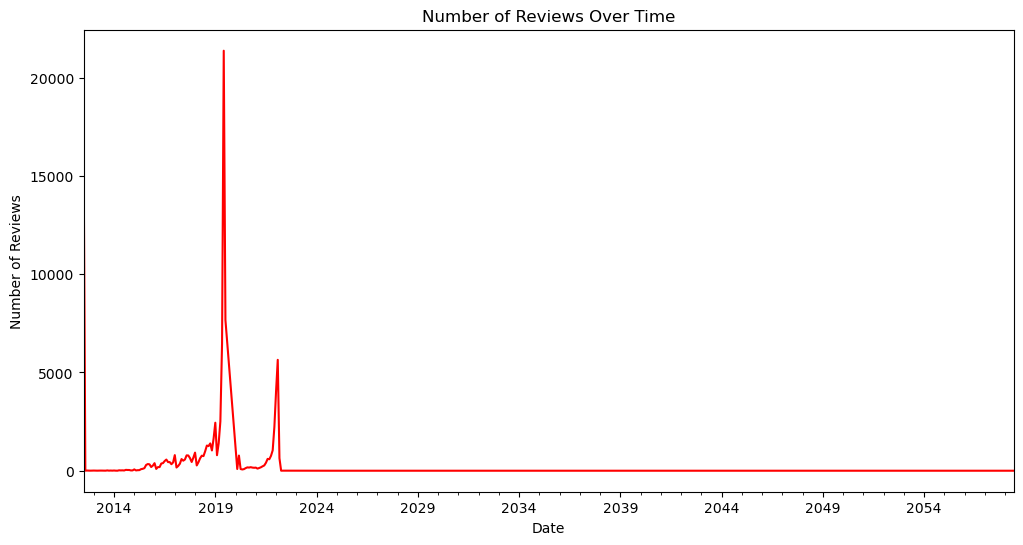

In [33]:
df['last review'] = pd.to_datetime(df['last review'])
reviews_over_time = df.groupby(df['last review'].dt.to_period("M")).size()

plt.figure(figsize=(12,6))
reviews_over_time.plot(kind='line',color='red')
plt.title("Number of Reviews Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.show()